# Combining images 

### We have now shifted our images 

### However, before we combine our images we need to scale them

### The atmosphere absorbs and scatters light from celestial objects 

### The closer to the horizon, the more light that is absorbed and scattered

### Clouds will also block light from celestial objects 

### For a combine to be effective we need stars to have the same flux in all the images 

###

###


In [2]:
# To use astropy we need to import libraries 


import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.time import Time
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from scipy.ndimage import shift

import os
import gc        

# Read in science images 

### I've just copied and modified this code from the previous notebook

### Printing the file names is a good cross check that I've loaded the right images 

###

In [3]:
images = ccdproc.ImageFileCollection('./',glob_include = 'sprocNGC_3293_V*fits')
for filename in images.files_filtered():
    print(filename)

# Load all of the images in the list 

scim=[]
for filename in images.files_filtered():
    scim.append(CCDData.read(filename))


Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'.


sprocNGC_3293_V_00003277.fits
sprocNGC_3293_V_00003280.fits
sprocNGC_3293_V_00003284.fits
sprocNGC_3293_V_00003388.fits
sprocNGC_3293_V_00003392.fits


# Reference stars 

### Let's identify some reference stars for measuring the flux densities 

### We can do this in ds9 and write down the coordinates 

### We need to avoid stars that are too bright - pixels have an upper limit near 60,000 counts

###

###


In [4]:
starxy = []
starxy.append([864,870])
starxy.append([567,920])
starxy.append([1051,865])
starxy.append([838,487])
starxy.append([575,457])
# Add some stars of your own

# Aperture Photometry 

### Photometry is measuring the brightness of celestial objects 

### In this case we will use uncalibrated photometry - just fluxes measured in ADU (analog-to-digital units) 

### The simplest form of photometry is aperture photometry 

### We define a region - an aperture - (often a circle) around an object and count up the ADU above the background level.

An aperture flux $F$ is defined by 

\begin{equation}
F = \sum f_i
\end{equation}

where $f_i$ is the counts above the background in the i-th pixel within the aperture (region)

###

### 

In [5]:
# Lets define 20 pixel radius apertures 

from photutils.aperture import CircularAperture
aperture = CircularAperture(starxy, r=20.0)   # Defining a series of 20 pixel radius aperture at the coordinates we defined

In [6]:
# Lets do photometry on the first image 

from photutils.aperture import aperture_photometry
phot_table = aperture_photometry(scim[0].data, aperture)

print(phot_table)

 id xcenter ycenter    aperture_sum   
--- ------- ------- ------------------
  1   864.0   870.0 255175.13950244582
  2   567.0   920.0  317128.8559680639
  3  1051.0   865.0  454259.5566331782
  4   838.0   487.0 202531.45343896377
  5   575.0   457.0  264712.8868330331


# Question 

### The stars in phot_table counts in the ballpark of 160,000

### This is on the order of 60,000 electrons (if the gain is 0.38)

### What would be the rough percentage uncertainty from photon statistics? 

### 

###

In [7]:
# Lets do photometry on all the images 

phot_tables=[]
for im in scim:
    phot_tables.append(aperture_photometry(im.data, aperture))

print(phot_tables)

[<QTable length=5>
  id  xcenter ycenter    aperture_sum   
int64 float64 float64      float64      
----- ------- ------- ------------------
    1   864.0   870.0 255175.13950244582
    2   567.0   920.0  317128.8559680639
    3  1051.0   865.0  454259.5566331782
    4   838.0   487.0 202531.45343896377
    5   575.0   457.0  264712.8868330331, <QTable length=5>
  id  xcenter ycenter    aperture_sum   
int64 float64 float64      float64      
----- ------- ------- ------------------
    1   864.0   870.0 226940.41810310606
    2   567.0   920.0  290642.6992822319
    3  1051.0   865.0  415078.8824719867
    4   838.0   487.0  175102.7278580761
    5   575.0   457.0 235157.61481438414, <QTable length=5>
  id  xcenter ycenter    aperture_sum   
int64 float64 float64      float64      
----- ------- ------- ------------------
    1   864.0   870.0  257019.2729281214
    2   567.0   920.0  321059.3772251141
    3  1051.0   865.0 463793.37474317476
    4   838.0   487.0  206892.4462664383


# Reference image 

### We need to define a reference image

### This should be taken in the best conditions

### This may be an exposure where we know the sky was perfectly clear

### For example, when combining data from multiple nights the reference image should be taken on a clear night

### If we don't know the image taken in the best conditions, choose highest signal-to-noise

###

###

In [8]:
# Reference image index 

refidx=3

# We now need to define scalings to multiply the other images to the reference image

scale=[]

for idx, phot_table in enumerate(phot_tables):
    x = phot_tables[refidx]['aperture_sum']/phot_table['aperture_sum']
    print(x)
    med=np.median(x)
    print('Median scale: ', med)
    scale.append(med)

print('Scales')
print(scale)

   aperture_sum   
------------------
 2.129468929715374
  2.13681489166105
 2.174236783921077
2.1992789647391517
2.1874128408725726
Median scale:  2.174236783921077
   aperture_sum   
------------------
 2.394406143022821
2.3315420056361216
2.3794702144265134
2.5437819884073045
2.4623330537693744
Median scale:  2.394406143022821
   aperture_sum   
------------------
2.1141898232597116
 2.110655255936826
2.1295427905292006
2.1529213525405333
2.1021530880113843
Median scale:  2.1141898232597116
aperture_sum
------------
         1.0
         1.0
         1.0
         1.0
         1.0
Median scale:  1.0
   aperture_sum   
------------------
 1.014777723705296
1.0088190100458803
1.0122270877036024
0.9839606872033806
0.9893669304390529
Median scale:  1.0088190100458803
Scales
[np.float64(2.174236783921077), np.float64(2.394406143022821), np.float64(2.1141898232597116), np.float64(1.0), np.float64(1.0088190100458803)]


In [9]:
# Lets apply these scales to the images 

sscim = []
for idx, im in enumerate(scim):
    sscim.append(im)
    sscim[-1].data=sscim[-1].data*scale[idx]


In [10]:
# Apply average and median combine

scim_av = ccdproc.combine(sscim, method='average', sigma_clip=False, minmax_clip=True, minmax_clip_min=-400)
scim_me = ccdproc.combine(sscim, method='median', sigma_clip=False, minmax_clip=True, minmax_clip_min=-400)


c:\Users\stanl\honours-env\.venv\Lib\site-packages\ccdproc\combiner.py:569: RuntimeWarning: Mean of empty slice
  mean = scale_func(data, axis=0)
c:\Users\stanl\honours-env\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\stanl\honours-env\.venv\Lib\site-packages\ccdproc\combiner.py:462: RuntimeWarning: All-NaN slice encountered
  medianed = median_func(data, axis=0)
c:\Users\stanl\honours-env\.venv\Lib\site-packages\astropy\stats\funcs.py:863: RuntimeWarning: All-NaN slice encountered
  data_median = func(data, axis=axis)
c:\Users\stanl\honours-env\.venv\Lib\site-packages\astropy\stats\funcs.py:872: RuntimeWarning: All-NaN slice encountered
  result = func(np.abs(data - data_median), axis=axis, overwrite_input=True)


-2.4077924991071313
-1000.0 1273.2793218512386


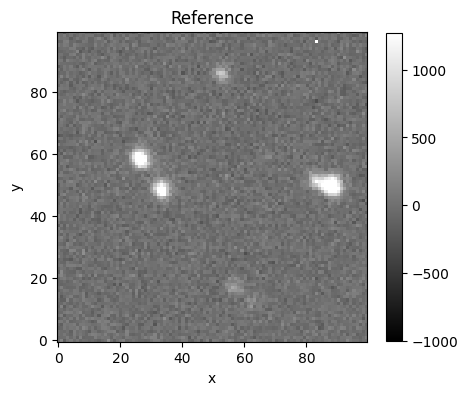

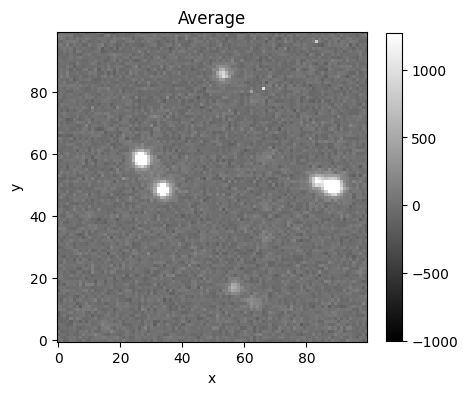

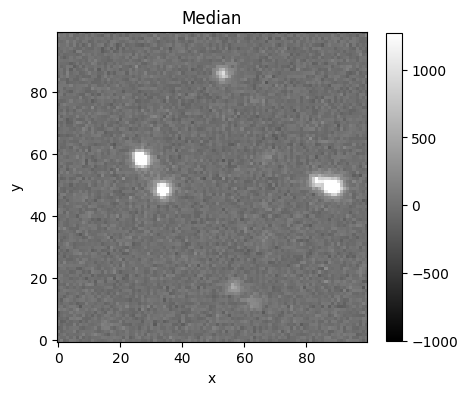

In [11]:
# Lets take a look

# Determine stats using the reference image 
med=np.median(scim[refidx].data)
print(med)
p1=np.percentile(scim[refidx].data, 1)
p99=np.percentile(scim[refidx].data, 99)
print(p1,p99)

# List of plot titles
title=['Reference', 'Average', 'Median']

for idx, im in enumerate([sscim[refidx], scim_av, scim_me]):
    skydata=im.data[900:1000,700:800]                    # Pick a region
    plt.rcParams['figure.figsize'] = [5, 5]              # Size of the image
    plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)  # Plot data
    ax = plt.gca()
    ax.invert_yaxis()                                    # y-axis 0 at bottom
    plt.colorbar(shrink=0.8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title[idx])
    plt.show()

# Comment 

In [12]:
scim_av.write('NGC_3293_V_average.fits', overwrite=True)
scim_me.write('NGC_3293_V_median.fits', overwrite=True)
              